In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_dir_1 = os.path.join('..', 'case_study_1', 'data')
data_dir_2 = os.path.join('..', 'case_study_2', 'data')
result_dir_1 = os.path.join('..', 'case_study_1', 'results')
result_dir_2 = os.path.join('..', 'case_study_2', 'results')

corrs_1 = pd.read_csv(os.path.join(data_dir_1, 'correlations.csv'), sep=";")
corrs_2 = pd.read_csv(os.path.join(data_dir_2, 'correlations.csv'), sep=";")

corr_matrix_1 = corrs_1.pivot(index='source', columns='target', values='correlation')
corr_matrix_2 = corrs_2.pivot(index='source', columns='target', values='spearman')
difference_matrix = corr_matrix_1 - corr_matrix_2

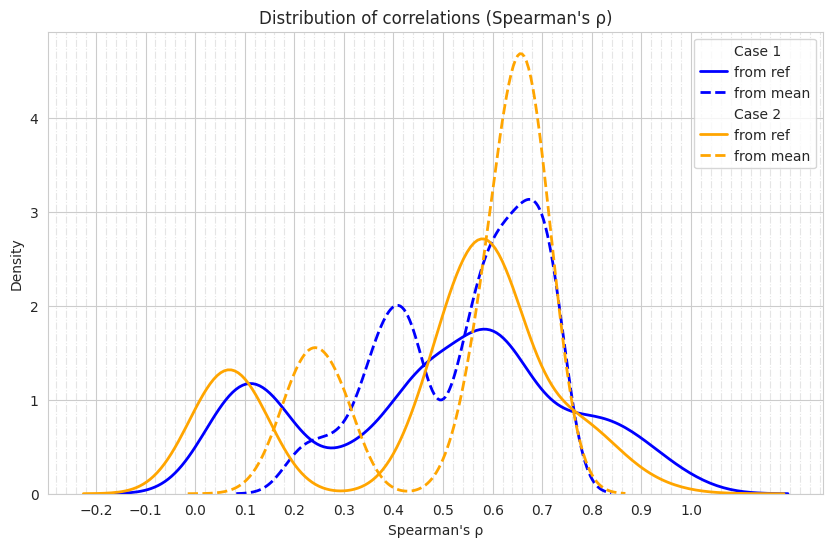

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the CSV for data_dir_1
df1 = pd.read_csv(os.path.join(data_dir_1, 'correlations.csv'), sep=";")
df1 = df1[df1["source"] != df1["target"]]  # Exclude self-correlations
df1 = df1[df1["source"] < df1["target"]]   # Exclude reverse pairs

# Load the CSV for data_dir_2
df2 = pd.read_csv(os.path.join(data_dir_2, 'correlations.csv'), sep=";")
df2 = df2[df2["source"] != df2["target"]]  # Exclude self-correlations
df2 = df2[df2["source"] < df2["target"]]   # Exclude reverse pairs

# Load the normalized_dataset.csv for study case 2
normalized_df = pd.read_csv(os.path.join(data_dir_2, 'normalized_dataset.csv'), sep=";")

# Plot the distributions as smooth curves (KDE)
plt.figure(figsize=(10, 6))

# Remove the following lines to exclude pairwise correlation:
# sns.kdeplot(df1["correlation"], fill=True, color="blue", linewidth=0.5, label="pairwise", alpha=0.5)
# sns.kdeplot(df2["spearman"], fill=True, color="orange", linewidth=0.5, label="pairwise", alpha=0.5)

# Plot the KDE for 'ref' and 'mean' for study case 1
ref_df1 = df1[df1["target"] == "ref"]["correlation"]
mean_df1 = df1[df1["target"] == "mean"]["correlation"]
sns.kdeplot(ref_df1, color="blue", linewidth=2, label="from ref")
sns.kdeplot(mean_df1, color="blue", linestyle="--", linewidth=2, label="from mean")

# Plot the KDE for 'ref' for study case 2
ref_df2 = df2[df2["target"] == "ref"]["spearman"]
sns.kdeplot(ref_df2, color="orange", linewidth=2, label="from ref")

# Plot the KDE for 'spearman_from_mean' from normalized_dataset.csv (study case 2)
sns.kdeplot(normalized_df["spearman_from_mean"], color="orange", linestyle="--", linewidth=2, label="from mean")

# Set x-axis ticks every 0.1
plt.xticks(np.arange(-0.2, 1.1, 0.1))

# Customize the legend to group by case
handles, labels = plt.gca().get_legend_handles_labels()
order = [0, 1, 2, 3]  # Order: Case 1 (from ref, from mean), Case 2 (from ref, from mean)
ordered_handles = [handles[i] for i in order]
ordered_labels = [labels[i] for i in order]

# Add section titles for each case
from matplotlib.lines import Line2D
custom_handles = [
    Line2D([0], [0], color='w', marker='', markersize=0, label='Case 1:'),
    ordered_handles[0], ordered_handles[1],
    Line2D([0], [0], color='w', marker='', markersize=0, label='Case 2:'),
    ordered_handles[2], ordered_handles[3]
]

custom_labels = [
    'Case 1',
    ordered_labels[0], ordered_labels[1],
    'Case 2',
    ordered_labels[2], ordered_labels[3]
]

plt.legend(custom_handles, custom_labels, loc='upper right', handletextpad=0.5)

plt.xlabel("Spearman's ρ")
plt.ylabel("Density")
plt.title("Distribution of correlations (Spearman's ρ)")
plt.minorticks_on()
plt.grid(True, linestyle="-.", alpha=0.5, which='minor', axis='x')
plt.savefig('correlations_distribution.svg', format='svg', bbox_inches='tight')
plt.savefig('correlations_distribution.png', format='png', bbox_inches='tight')
plt.show()


/home/ymerel/fmri/sosym_2026/.venv/lib64/python3.13/site-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')
/home/ymerel/fmri/sosym_2026/.venv/lib64/python3.13/site-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')


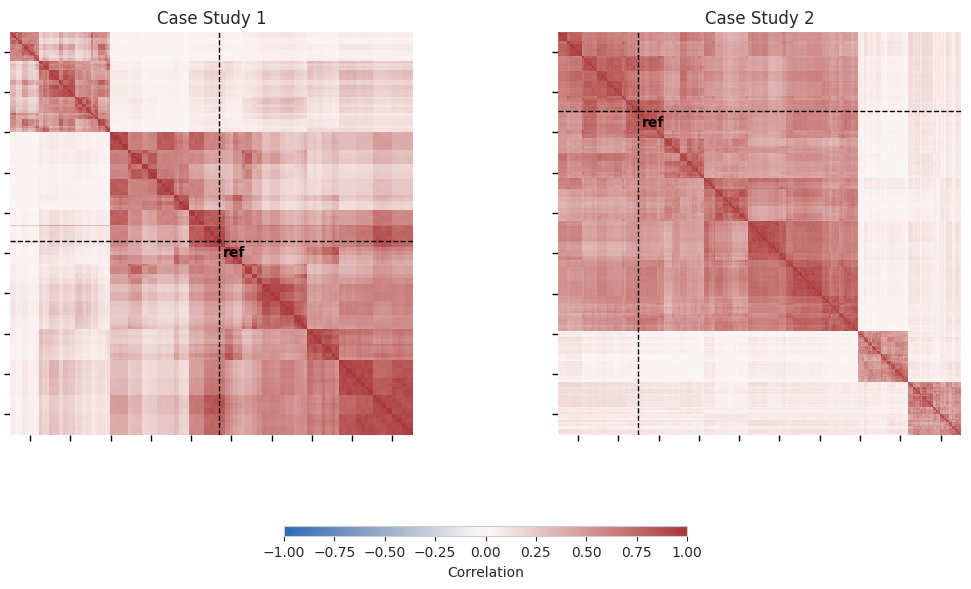

In [24]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import ward, leaves_list
from matplotlib.colors import LinearSegmentedColormap

# Define colormap
# cmap = LinearSegmentedColormap.from_list("red_cmap", ["#FFCCCC", "#FF0000"])
cmap = 'vlag'

def load_and_process(datadir, corr_column='correlation'):
    ds_path = os.path.join(datadir, 'normalized_dataset.csv')
    corr_path = os.path.join(datadir, 'correlations.csv')
    dataset = pd.read_csv(ds_path, delimiter=';')
    correlations = pd.read_csv(corr_path, delimiter=';')
    matrix = correlations.pivot(index='source', columns='target', values=corr_column).fillna(1.0)

    # Compute distance matrix (1 - correlation)
    distance_matrix = 1 - matrix.values
    np.fill_diagonal(distance_matrix, 0)  # Ensure diagonal is zero

    # Use Ward's method for linkage
    ward_linkage = ward(distance_matrix)

    # Get the order of leaves (items) after clustering
    sorted_index = leaves_list(ward_linkage)
    sorted_ids = matrix.index[sorted_index]

    # Reorder the matrix
    matrix = matrix.reindex(index=sorted_ids, columns=sorted_ids)
    return matrix, dataset, sorted_ids

# Load data
matrix_1, ds_1, sorted_ids_1 = load_and_process(os.path.join('..', 'case_study_1', 'data'), 'correlation')
matrix_2, ds_2, sorted_ids_2 = load_and_process(os.path.join('..', 'case_study_2', 'data'), 'spearman')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Plot heatmaps
sns.heatmap(matrix_1, ax=ax1, cbar=False, cmap=cmap, square=True, vmin=-1, vmax=1)
sns.heatmap(matrix_2, ax=ax2, cbar=False, cmap=cmap, square=True, vmin=-1, vmax=1)

def set_axis_ticks(ax, matrix):
    n = len(matrix)
    step = max(1, n // 10)  # One tick every 100 configs (10 ticks total)
    ticks = np.arange(step // 2, n, step)

    # Set ticks
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    # Remove tick labels
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Ensure ticks are visible
    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=False,
        labelleft=False,
        length=4,
        width=1,
        colors='black'
    )

# Apply custom ticks
set_axis_ticks(ax1, matrix_1)
set_axis_ticks(ax2, matrix_2)

# Find the index of 'ref' in the sorted IDs
ref_index_1 = np.where(sorted_ids_1 == 'ref')[0][0]
ref_index_2 = np.where(sorted_ids_2 == 'ref')[0][0]

# Draw crossing lines at 'ref' position for both heatmaps
ax1.axvline(x=ref_index_1, color='black', linestyle='--', linewidth=1.0)
ax1.axhline(y=ref_index_1, color='black', linestyle='--', linewidth=1.0)
ax2.axvline(x=ref_index_2, color='black', linestyle='--', linewidth=1.0)
ax2.axhline(y=ref_index_2, color='black', linestyle='--', linewidth=1.0)

# Add 'ref' label slightly bottom-right of the intersection
offset = 10  # Adjust this value to move the label further away from the cross
ax1.text(ref_index_1 + offset, ref_index_1 + offset, 'ref',
         ha='left', va='top', color='black', fontsize=10, fontweight='bold')
ax2.text(ref_index_2 + offset, ref_index_2 + offset, 'ref',
         ha='left', va='top', color='black', fontsize=10, fontweight='bold')

# Remove x and y axis labels
ax1.set_xlabel('')
ax1.set_ylabel('')
ax2.set_xlabel('')
ax2.set_ylabel('')

# Spacing and Colorbar
plt.subplots_adjust(wspace=0.02, bottom=0.25)
cbar = fig.colorbar(ax1.collections[0], ax=[ax1, ax2], location='bottom', fraction=0.02, pad=0.18, aspect=40)
cbar.set_label('Correlation')

ax1.set_title('Case Study 1')
ax2.set_title('Case Study 2')
plt.savefig('correlations_heatmap.png', format='png', bbox_inches='tight', dpi=300)
plt.show()


1001 configs in dataset
1004003 correlations in matrix


/home/ymerel/fmri/sosym_2026/.venv/lib64/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 2000x2000 with 0 Axes>

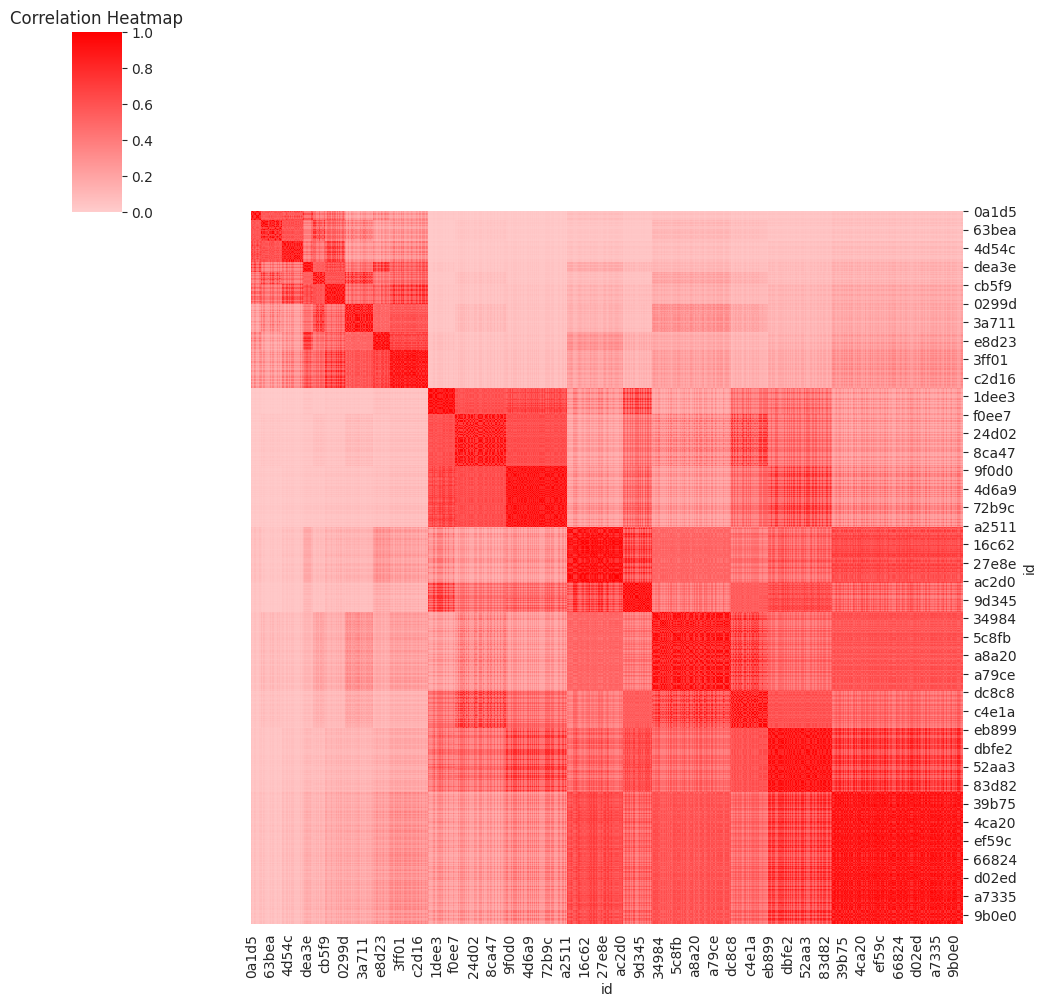

In [4]:
from utils import clusterize_hierch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

datadir = os.path.join('..', 'case_study_1', 'data')
ds_path = os.path.join(datadir, 'normalized_dataset.csv')
corr_path = os.path.join(datadir, 'correlations.csv')

plt.figure(figsize=(20, 20))
cmap = LinearSegmentedColormap.from_list("red_cmap", ["#FFCCCC", "#FF0000"])

threshold = 0.20

dataset = pd.read_csv(ds_path, delimiter=';')

print(f"{len(dataset)} configs in dataset")

correlations = pd.read_csv(corr_path, delimiter=';')
print(f"{len(correlations)} correlations in matrix")

matrix = correlations.pivot(index='source', columns='target', values='correlation').fillna(1.0)

ds, distance_matrix, Z, clusters = clusterize_hierch(dataset, correlations, dataset['id'], None, 'correlation', threshold)

# reorder matrix by cluster
sorted_index = ds.sort_values('cluster', ascending=False)['id']
matrix = matrix.reindex(index=sorted_index, columns=sorted_index)
matrix.index = matrix.index.str.slice(0, 5)
matrix.columns = matrix.columns.str.slice(0, 5)
map = sns.clustermap(matrix, cmap=cmap, vmin=0, vmax=1, row_cluster=False, col_cluster=False, row_linkage=Z, col_linkage=Z, square=True)
plt.title('Correlation Heatmap')
plt.show()

1001 configs in dataset
1002001 correlations in matrix


<Figure size 2000x2000 with 0 Axes>

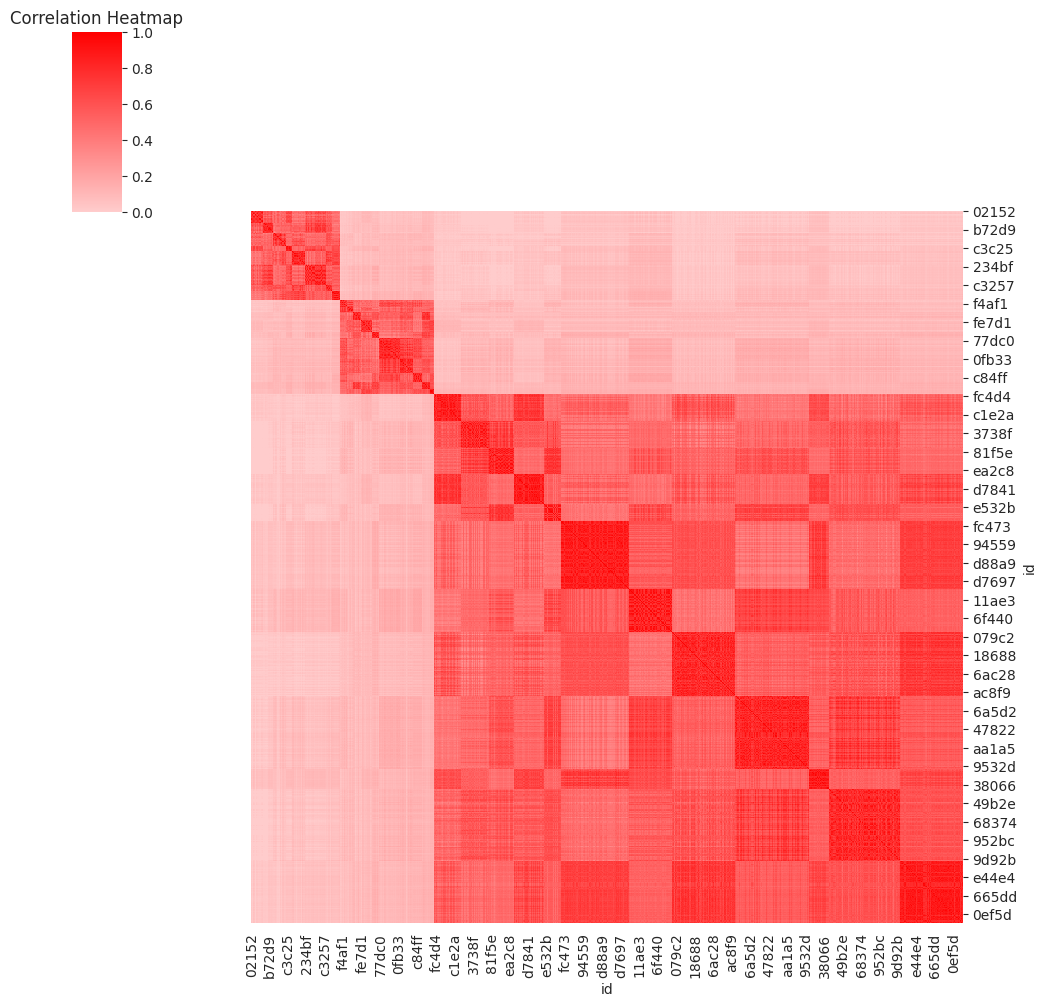

In [5]:
from utils import clusterize_hierch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

datadir = os.path.join('..', 'case_study_2', 'data')
ds_path = os.path.join(datadir, 'normalized_dataset.csv')
corr_path = os.path.join(datadir, 'correlations.csv')

plt.figure(figsize=(20, 20))
cmap = LinearSegmentedColormap.from_list("red_cmap", ["#FFCCCC", "#FF0000"])

threshold = 0.20

dataset = pd.read_csv(ds_path, delimiter=';')

print(f"{len(dataset)} configs in dataset")

correlations = pd.read_csv(corr_path, delimiter=';')
print(f"{len(correlations)} correlations in matrix")

matrix = correlations.pivot(index='source', columns='target', values='spearman').fillna(1.0)

ds, distance_matrix, Z, clusters = clusterize_hierch(dataset, correlations, dataset['id'], None, 'spearman', threshold)

# reorder matrix by cluster
sorted_index = ds.sort_values('cluster', ascending=False)['id']
matrix = matrix.reindex(index=sorted_index, columns=sorted_index)
matrix.index = matrix.index.str.slice(0, 5)
matrix.columns = matrix.columns.str.slice(0, 5)
map = sns.clustermap(matrix, cmap=cmap, vmin=0, vmax=1, row_cluster=False, col_cluster=False, row_linkage=Z, col_linkage=Z)
plt.title('Correlation Heatmap')
plt.show()